# Fraud Detection — Undersampled Training (Group 22)

This notebook retrains all models from `train_model.ipynb` on the **undersampled dataset**:
- All **187 fraud** cases kept
- **1,870 non-fraud** cases randomly sampled (10:1 ratio)
- Total dataset: **2,057 rows**

The undersampled CSV was generated with `random_state=42` for reproducibility.

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, precision_recall_curve, auc,
    average_precision_score, PrecisionRecallDisplay
)
from sklearn.pipeline import Pipeline

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.ensemble import BalancedRandomForestClassifier

from xgboost import XGBClassifier
import joblib
import os
import json

print('All imports successful!')

All imports successful!


## 1. Load Undersampled Data

In [ ]:

df = pd.read_csv('../data/processed/medicare_labeled_balanced.csv')

print('Dataset shape:', df.shape)
print('\nClass distribution:')
print(df['fraud_label'].value_counts())
print('\nFraud rate: {:.2%}'.format(df['fraud_label'].mean()))

Dataset shape: (2057, 59)

Class distribution:
fraud_label
0    1870
1     187
Name: count, dtype: int64

Fraud rate: 9.09%


In [ ]:


# Drop non-feature columns
DROP_COLS = ['fraud_label', 'Rndrng_NPI', 'Rndrng_Prvdr_City', 
             'Rndrng_Prvdr_Cntry', 'Rndrng_Prvdr_Type']

X = df.drop(columns=[c for c in DROP_COLS if c in df.columns], errors='ignore')
y = df['fraud_label']

# Keep only numeric columns (same as original notebook)
X = X.select_dtypes(include=['number', 'bool'])

print('Feature matrix shape:', X.shape)
print('Features:', X.columns.tolist())

# Stratified split — ensures fraud cases appear in both train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'\nTrain size: {len(X_train)} | Fraud in train: {y_train.sum()} ({y_train.mean():.2%})')
print(f'Test size:  {len(X_test)}  | Fraud in test:  {y_test.sum()} ({y_test.mean():.2%})')

Feature matrix shape: (2057, 54)
Features: ['Tot_HCPCS_Cds', 'Tot_Benes', 'Tot_Srvcs', 'Tot_Sbmtd_Chrg', 'Tot_Mdcr_Alowd_Amt', 'Tot_Mdcr_Pymt_Amt', 'Tot_Mdcr_Stdzd_Amt', 'Tot_HCPCS_Cds_was_missing', 'Tot_Benes_was_missing', 'Tot_Srvcs_was_missing', 'Tot_Sbmtd_Chrg_was_missing', 'Tot_Mdcr_Alowd_Amt_was_missing', 'Tot_Mdcr_Pymt_Amt_was_missing', 'Tot_Mdcr_Stdzd_Amt_was_missing', 'Rndrng_Prvdr_City_was_missing', 'Rndrng_Prvdr_Cntry_was_missing', 'Rndrng_Prvdr_Type_was_missing', 'payment_per_service', 'charge_to_payment_ratio', 'services_per_beneficiary', 'allowed_to_submitted_ratio', 'standardized_to_payment_ratio', 'beneficiaries_per_hcpcs', 'services_per_hcpcs', 'submitted_per_beneficiary', 'payment_per_beneficiary', 'log_Tot_HCPCS_Cds', 'log_Tot_Benes', 'log_Tot_Srvcs', 'log_Tot_Sbmtd_Chrg', 'log_Tot_Mdcr_Alowd_Amt', 'log_Tot_Mdcr_Pymt_Amt', 'log_Tot_Mdcr_Stdzd_Amt', 'log_payment_per_service', 'log_charge_to_payment_ratio', 'log_services_per_beneficiary', 'log_submitted_per_beneficiary

## 2. Helper Functions

In [ ]:

def evaluate_model(model, X_test, y_test, name, threshold=0.5):
    """Full evaluation: classification report, ROC-AUC, AUPRC, Precision@K."""
    y_probs = model.predict_proba(X_test)[:, 1]
    y_pred  = (y_probs >= threshold).astype(int)

    sep = '=' * 55
    print(f'\n{sep}')
    print(sep)
    
    print(classification_report(y_test, y_pred, digits=4))
    print('Confusion Matrix:')
    print(confusion_matrix(y_test, y_pred))

    roc = roc_auc_score(y_test, y_probs)
    precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_probs)
    auprc = auc(recall_curve, precision_curve)
    ap    = average_precision_score(y_test, y_probs)

    print(f'\nROC-AUC : {roc:.4f}')
    print(f'AUPRC   : {auprc:.4f}')
    print(f'Avg Prec: {ap:.4f}')

    for k in [20, 50, 100]:
        if k <= len(y_test):
            top_k = np.argsort(y_probs)[::-1][:k]
            pk = np.array(y_test)[top_k].mean()
            print(f'Precision@{k:<4}: {pk:.4f}')

    return y_probs


def precision_at_k(y_true, y_scores, k=100):
    y_true   = np.array(y_true)
    y_scores = np.array(y_scores)
    top_k    = np.argsort(y_scores)[::-1][:k]
    return y_true[top_k].mean()


print('Helper functions defined.')

Helper functions defined.


## 3. Model 1 — Logistic Regression (Baseline)

In [ ]:

print('Training Logistic Regression...')

lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        class_weight='balanced',
        penalty='l2',
        C=0.1,
        solver='liblinear',
        random_state=42
    ))
])

lr_pipeline.fit(X_train, y_train)
y_probs_lr = evaluate_model(lr_pipeline, X_test, y_test, 'Logistic Regression (Baseline)')

Training Logistic Regression...

              precision    recall  f1-score   support

           0     0.9406    0.7600    0.8407       375
           1     0.1743    0.5135    0.2603        37

    accuracy                         0.7379       412
   macro avg     0.5575    0.6368    0.5505       412
weighted avg     0.8718    0.7379    0.7886       412

Confusion Matrix:
[[285  90]
 [ 18  19]]

ROC-AUC : 0.6722
AUPRC   : 0.1552
Avg Prec: 0.1658
Precision@20  : 0.1000
Precision@50  : 0.2200
Precision@100 : 0.1700


## 4. Model 2 — Random Forest

In [ ]:

print('Training Random Forest...')

rf_clf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced_subsample',
    max_depth=8,
    min_samples_leaf=5,   # was 50 — reduced for smaller dataset
    max_features='sqrt',
    n_jobs=-1,
    random_state=42
)

rf_clf.fit(X_train, y_train)
y_probs_rf = evaluate_model(rf_clf, X_test, y_test, 'Random Forest')

Training Random Forest...

              precision    recall  f1-score   support

           0     0.9213    0.9680    0.9441       375
           1     0.3333    0.1622    0.2182        37

    accuracy                         0.8956       412
   macro avg     0.6273    0.5651    0.5811       412
weighted avg     0.8685    0.8956    0.8789       412

Confusion Matrix:
[[363  12]
 [ 31   6]]

ROC-AUC : 0.7052
AUPRC   : 0.1920
Avg Prec: 0.2037
Precision@20  : 0.3000
Precision@50  : 0.2400
Precision@100 : 0.1800


## 5. Model 3 — SMOTE + Random Forest

In [ ]:

print('Training SMOTE + Random Forest...')

smote_rf_pipeline = ImbPipeline([
    ('smote', SMOTE(sampling_strategy=0.5, random_state=42, k_neighbors=5)),
    ('rf', RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        max_features='sqrt',
        min_samples_leaf=5,
        n_jobs=-1,
        random_state=42
    ))
])

smote_rf_pipeline.fit(X_train, y_train)
y_probs_smote_rf = evaluate_model(smote_rf_pipeline, X_test, y_test, 'SMOTE + Random Forest')

Training SMOTE + Random Forest...

              precision    recall  f1-score   support

           0     0.9171    0.9440    0.9304       375
           1     0.1923    0.1351    0.1587        37

    accuracy                         0.8714       412
   macro avg     0.5547    0.5396    0.5445       412
weighted avg     0.8520    0.8714    0.8611       412

Confusion Matrix:
[[354  21]
 [ 32   5]]

ROC-AUC : 0.7018
AUPRC   : 0.2134
Avg Prec: 0.2223
Precision@20  : 0.2500
Precision@50  : 0.1800
Precision@100 : 0.1900


## 6. Model 4 — Balanced Random Forest

In [ ]:

print('Training Balanced Random Forest...')

brf = BalancedRandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    sampling_strategy='auto',
    replacement=True,
    bootstrap=True,
    n_jobs=-1,
    random_state=42
)

brf.fit(X_train, y_train)
y_probs_brf = evaluate_model(brf, X_test, y_test, 'Balanced Random Forest')

Training Balanced Random Forest...

              precision    recall  f1-score   support

           0     0.9432    0.6640    0.7793       375
           1     0.1486    0.5946    0.2378        37

    accuracy                         0.6578       412
   macro avg     0.5459    0.6293    0.5086       412
weighted avg     0.8718    0.6578    0.7307       412

Confusion Matrix:
[[249 126]
 [ 15  22]]

ROC-AUC : 0.6940
AUPRC   : 0.1778
Avg Prec: 0.1910
Precision@20  : 0.2500
Precision@50  : 0.1800
Precision@100 : 0.1500


## 7. Model 5 — XGBoost (Base)

In [ ]:

print('Training XGBoost (Base)...')

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight: {scale_pos_weight:.2f}')

xgb_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=3,
    gamma=1,
    reg_alpha=1,
    reg_lambda=2,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=-1,
    eval_metric='aucpr'
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

y_probs_xgb = evaluate_model(xgb_model, X_test, y_test, 'XGBoost (Base)')

Training XGBoost (Base)...
scale_pos_weight: 9.97
[0]	validation_0-aucpr:0.14153
[50]	validation_0-aucpr:0.18696
[100]	validation_0-aucpr:0.17413
[105]	validation_0-aucpr:0.17189

              precision    recall  f1-score   support

           0     0.9384    0.8533    0.8939       375
           1     0.2254    0.4324    0.2963        37

    accuracy                         0.8155       412
   macro avg     0.5819    0.6429    0.5951       412
weighted avg     0.8744    0.8155    0.8402       412

Confusion Matrix:
[[320  55]
 [ 21  16]]

ROC-AUC : 0.7119
AUPRC   : 0.1922
Avg Prec: 0.2008
Precision@20  : 0.2000
Precision@50  : 0.2600
Precision@100 : 0.2000


## 8. Model 6 — SMOTE + XGBoost

In [ ]:

print('Training SMOTE + XGBoost...')

smote = SMOTE(sampling_strategy=0.5, random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print('After SMOTE distribution:')
print(pd.Series(y_train_smote).value_counts())

xgb_smote_model = XGBClassifier(
    n_estimators=600,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=5,
    gamma=1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1,
    reg_lambda=2,
    objective='binary:logistic',
    random_state=42,
    n_jobs=-1,
    eval_metric='aucpr',
    early_stopping_rounds=50
)

xgb_smote_model.fit(
    X_train_smote, y_train_smote,
    eval_set=[(X_test, y_test)],
    verbose=50
)

y_probs_smote_xgb = evaluate_model(xgb_smote_model, X_test, y_test, 'SMOTE + XGBoost')

Training SMOTE + XGBoost...
After SMOTE distribution:
fraud_label
0    1495
1     747
Name: count, dtype: int64
[0]	validation_0-aucpr:0.13312
[50]	validation_0-aucpr:0.23307
[100]	validation_0-aucpr:0.24231
[101]	validation_0-aucpr:0.24327

              precision    recall  f1-score   support

           0     0.9282    0.9307    0.9294       375
           1     0.2778    0.2703    0.2740        37

    accuracy                         0.8714       412
   macro avg     0.6030    0.6005    0.6017       412
weighted avg     0.8698    0.8714    0.8706       412

Confusion Matrix:
[[349  26]
 [ 27  10]]

ROC-AUC : 0.7186
AUPRC   : 0.2450
Avg Prec: 0.2524
Precision@20  : 0.3000
Precision@50  : 0.2000
Precision@100 : 0.2000


## 9. Model 7 — Tuned XGBoost (RandomizedSearchCV)

In [ ]:

from sklearn.model_selection import RandomizedSearchCV

print('Hyperparameter tuning XGBoost...')

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_base = XGBClassifier(
    objective='binary:logistic',
    eval_metric='aucpr',
    random_state=42,
    n_jobs=-1
)

param_dist = {
    'n_estimators':      [200, 400, 600, 800],
    'learning_rate':     [0.01, 0.03, 0.05, 0.1],
    'max_depth':         [3, 4, 5, 6],
    'min_child_weight':  [2, 3, 5, 8],
    'gamma':             [0, 1, 2],
    'subsample':         [0.6, 0.7, 0.8, 0.9],
    'colsample_bytree':  [0.6, 0.7, 0.8, 0.9],
    'reg_alpha':         [0, 0.5, 1, 2],
    'reg_lambda':        [1, 2, 4, 6],
    'scale_pos_weight':  [scale_pos_weight, scale_pos_weight * 0.75, scale_pos_weight * 1.25]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=10,
    scoring='average_precision',
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=1
)

random_search.fit(X_train, y_train)

print('\nBest CV score (Average Precision):', random_search.best_score_)
print('\nBest parameters:')
print(random_search.best_params_)

Hyperparameter tuning XGBoost...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best CV score (Average Precision): 0.2416547658865588

Best parameters:
{'subsample': 0.6, 'scale_pos_weight': np.float64(7.475), 'reg_lambda': 4, 'reg_alpha': 0, 'n_estimators': 800, 'min_child_weight': 8, 'max_depth': 5, 'learning_rate': 0.05, 'gamma': 2, 'colsample_bytree': 0.6}


In [ ]:

print('Training Best Tuned XGBoost...')

best_xgb = XGBClassifier(
    **random_search.best_params_,
    objective='binary:logistic',
    eval_metric='aucpr',
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=-1
)

best_xgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

y_probs_best_xgb = evaluate_model(best_xgb, X_test, y_test, 'Tuned XGBoost')

Training Best Tuned XGBoost...
[0]	validation_0-aucpr:0.16930
[50]	validation_0-aucpr:0.19782
[100]	validation_0-aucpr:0.19291
[106]	validation_0-aucpr:0.18915

              precision    recall  f1-score   support

           0     0.9373    0.9173    0.9272       375
           1     0.3111    0.3784    0.3415        37

    accuracy                         0.8689       412
   macro avg     0.6242    0.6479    0.6343       412
weighted avg     0.8811    0.8689    0.8746       412

Confusion Matrix:
[[344  31]
 [ 23  14]]

ROC-AUC : 0.6863
AUPRC   : 0.2083
Avg Prec: 0.2184
Precision@20  : 0.4500
Precision@50  : 0.2800
Precision@100 : 0.1800


## 10. Model 8 — Improved XGBoost

In [ ]:

print('Training Improved XGBoost...')

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight: {scale_pos_weight:.2f}')

improved_xgb = XGBClassifier(
    objective='binary:logistic',
    n_estimators=800,
    learning_rate=0.01,
    max_depth=4,
    min_child_weight=5,
    gamma=1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1,
    reg_lambda=4,
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',
    early_stopping_rounds=80,
    random_state=42,
    n_jobs=-1
)

improved_xgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

y_probs_improved_xgb = evaluate_model(improved_xgb, X_test, y_test, 'Improved XGBoost')

Training Improved XGBoost...
scale_pos_weight: 9.97
[0]	validation_0-aucpr:0.13985
[50]	validation_0-aucpr:0.17099
[100]	validation_0-aucpr:0.17657
[150]	validation_0-aucpr:0.17585
[163]	validation_0-aucpr:0.17813

              precision    recall  f1-score   support

           0     0.9369    0.8320    0.8814       375
           1     0.2025    0.4324    0.2759        37

    accuracy                         0.7961       412
   macro avg     0.5697    0.6322    0.5786       412
weighted avg     0.8710    0.7961    0.8270       412

Confusion Matrix:
[[312  63]
 [ 21  16]]

ROC-AUC : 0.6981
AUPRC   : 0.1834
Avg Prec: 0.1939
Precision@20  : 0.2500
Precision@50  : 0.2200
Precision@100 : 0.2100


## 11. Threshold Tuning (Improved XGBoost)

In [ ]:

print('Threshold Tuning for Improved XGBoost...')

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
results = []

for th in thresholds:
    y_pred_th = (y_probs_improved_xgb >= th).astype(int)
    cm = confusion_matrix(y_test, y_pred_th)
    tn, fp, fn, tp = cm.ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    results.append([th, precision, recall, f1, tp, fp, fn])

thresh_df = pd.DataFrame(results, columns=['Threshold', 'Precision', 'Recall', 'F1', 'TP', 'FP', 'FN'])
print(thresh_df.to_string(index=False))

Threshold Tuning for Improved XGBoost...
 Threshold  Precision   Recall       F1  TP  FP  FN
       0.1   0.089806 1.000000 0.164811  37 375   0
       0.2   0.089806 1.000000 0.164811  37 375   0
       0.3   0.098930 1.000000 0.180049  37 337   0
       0.4   0.117155 0.756757 0.202899  28 211   9
       0.5   0.202532 0.432432 0.275862  16  63  21
       0.6   0.241379 0.189189 0.212121   7  22  30
       0.7   0.000000 0.000000 0.000000   0   0  37


## 12. Weighted Ensemble (Improved XGBoost + BRF)

In [ ]:

print('Searching best ensemble weights...')

xgb_probs = y_probs_improved_xgb
brf_probs = y_probs_brf

# Baseline: simple average
baseline_probs = (xgb_probs + brf_probs) / 2
baseline_roc   = roc_auc_score(y_test, baseline_probs)
baseline_auprc = average_precision_score(y_test, baseline_probs)
print(f'\nBaseline Ensemble (50/50) — ROC-AUC: {baseline_roc:.4f} | AUPRC: {baseline_auprc:.4f}')

# Grid search over weights
best_auprc   = -1
best_weights = None
best_probs   = None
weight_results = []

for w_xgb in np.arange(0.1, 1.0, 0.1):
    w_brf = round(1 - w_xgb, 1)
    ens_probs = w_xgb * xgb_probs + w_brf * brf_probs
    roc   = roc_auc_score(y_test, ens_probs)
    auprc = average_precision_score(y_test, ens_probs)
    weight_results.append([round(w_xgb,1), round(w_brf,1), roc, auprc])
    if auprc > best_auprc:
        best_auprc   = auprc
        best_weights = (round(w_xgb,1), round(w_brf,1))
        best_probs   = ens_probs

weight_df = pd.DataFrame(weight_results, columns=['w_XGB', 'w_BRF', 'ROC-AUC', 'AUPRC'])
print('\nWeight search results:')
print(weight_df.to_string(index=False))
print(f'\nBest Weights → XGBoost: {best_weights[0]} | BRF: {best_weights[1]}')
print(f'Best AUPRC : {best_auprc:.4f}')

Searching best ensemble weights...

Baseline Ensemble (50/50) — ROC-AUC: 0.7058 | AUPRC: 0.1946

Weight search results:
 w_XGB  w_BRF  ROC-AUC    AUPRC
   0.1    0.9 0.697586 0.188516
   0.2    0.8 0.701261 0.190785
   0.3    0.7 0.703640 0.192176
   0.4    0.6 0.705369 0.188483
   0.5    0.5 0.705802 0.194550
   0.6    0.4 0.705369 0.194774
   0.7    0.3 0.703856 0.190347
   0.8    0.2 0.702342 0.190906
   0.9    0.1 0.699604 0.190895

Best Weights → XGBoost: 0.6 | BRF: 0.4
Best AUPRC : 0.1948


In [ ]:

print('\n===== FINAL ENSEMBLE RESULTS =====')

final_roc   = roc_auc_score(y_test, best_probs)
final_auprc = average_precision_score(y_test, best_probs)
final_preds = (best_probs >= 0.5).astype(int)

print(f'ROC-AUC : {final_roc:.4f}')
print(f'AUPRC   : {final_auprc:.4f}')
print(f'Weights → XGBoost: {best_weights[0]} | BRF: {best_weights[1]}')
print('\nClassification Report:')
print(classification_report(y_test, final_preds, digits=4))
print('Confusion Matrix:')
print(confusion_matrix(y_test, final_preds))

for k in [20, 50, 100]:
    if k <= len(y_test):
        print(f'Precision@{k}: {precision_at_k(y_test, best_probs, k):.4f}')


===== FINAL ENSEMBLE RESULTS =====
ROC-AUC : 0.7054
AUPRC   : 0.1948
Weights → XGBoost: 0.6 | BRF: 0.4

Classification Report:
              precision    recall  f1-score   support

           0     0.9437    0.7600    0.8419       375
           1     0.1818    0.5405    0.2721        37

    accuracy                         0.7403       412
   macro avg     0.5628    0.6503    0.5570       412
weighted avg     0.8753    0.7403    0.7908       412

Confusion Matrix:
[[285  90]
 [ 17  20]]
Precision@20: 0.2000
Precision@50: 0.2400
Precision@100: 0.2000


## 13. Model Comparison Summary


===== MODEL COMPARISON (Undersampled Data) =====
              Model  ROC-AUC  AUPRC  P@100
Logistic Regression   0.6722 0.1658   0.17
      Random Forest   0.7052 0.2037   0.18
         SMOTE + RF   0.7018 0.2223   0.19
        Balanced RF   0.6940 0.1910   0.15
     XGBoost (Base)   0.7119 0.2008   0.20
    SMOTE + XGBoost   0.7186 0.2524   0.20
      Tuned XGBoost   0.6863 0.2184   0.18
   Improved XGBoost   0.6981 0.1939   0.21
    Ensemble (Best)   0.7054 0.1948   0.20


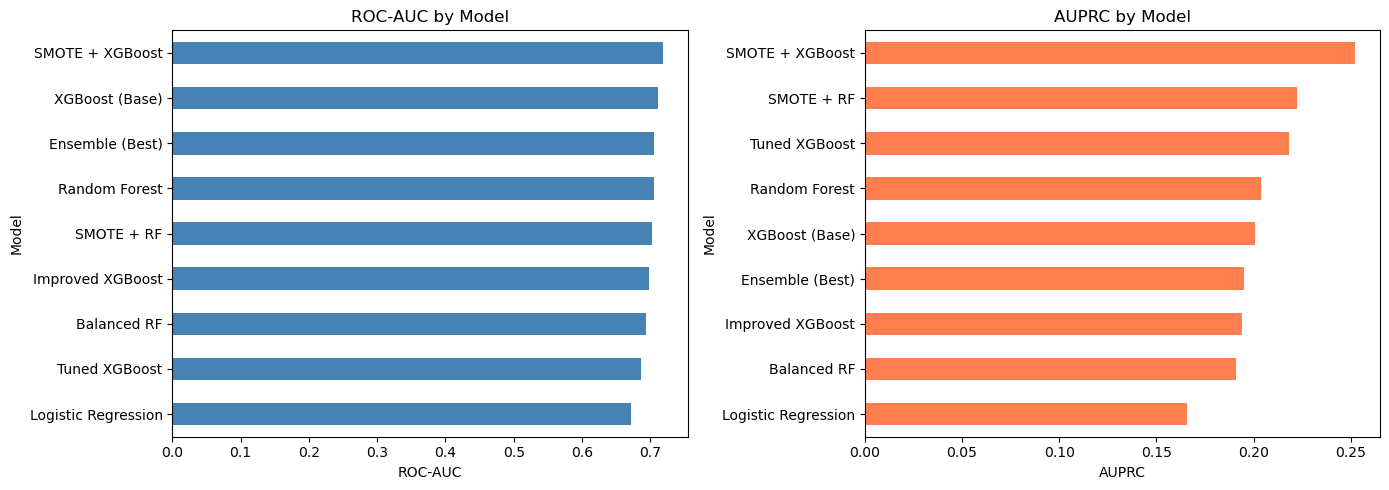

Plot saved as model_comparison_undersampled.png


In [ ]:

models = {
    'Logistic Regression':  y_probs_lr,
    'Random Forest':         y_probs_rf,
    'SMOTE + RF':            y_probs_smote_rf,
    'Balanced RF':           y_probs_brf,
    'XGBoost (Base)':        y_probs_xgb,
    'SMOTE + XGBoost':       y_probs_smote_xgb,
    'Tuned XGBoost':         y_probs_best_xgb,
    'Improved XGBoost':      y_probs_improved_xgb,
    'Ensemble (Best)':       best_probs
}

summary = []
for name, probs in models.items():
    roc   = roc_auc_score(y_test, probs)
    auprc = average_precision_score(y_test, probs)
    p100  = precision_at_k(y_test, probs, k=min(100, len(y_test)))
    summary.append({'Model': name, 'ROC-AUC': round(roc,4), 'AUPRC': round(auprc,4), 'P@100': round(p100,4)})

summary_df = pd.DataFrame(summary)
print('\n===== MODEL COMPARISON (Undersampled Data) =====')
print(summary_df.to_string(index=False))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
summary_df.sort_values('ROC-AUC').plot(x='Model', y='ROC-AUC', kind='barh', ax=axes[0], legend=False, color='steelblue')
axes[0].set_title('ROC-AUC by Model')
axes[0].set_xlabel('ROC-AUC')
summary_df.sort_values('AUPRC').plot(x='Model', y='AUPRC', kind='barh', ax=axes[1], legend=False, color='coral')
axes[1].set_title('AUPRC by Model')
axes[1].set_xlabel('AUPRC')
plt.tight_layout()
plt.savefig('model_comparison_undersampled.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved as model_comparison_undersampled.png')

## 14. Feature Importance (SHAP)

In [27]:
import shap
print(shap.__version__)

0.49.1


SHAP values computed.


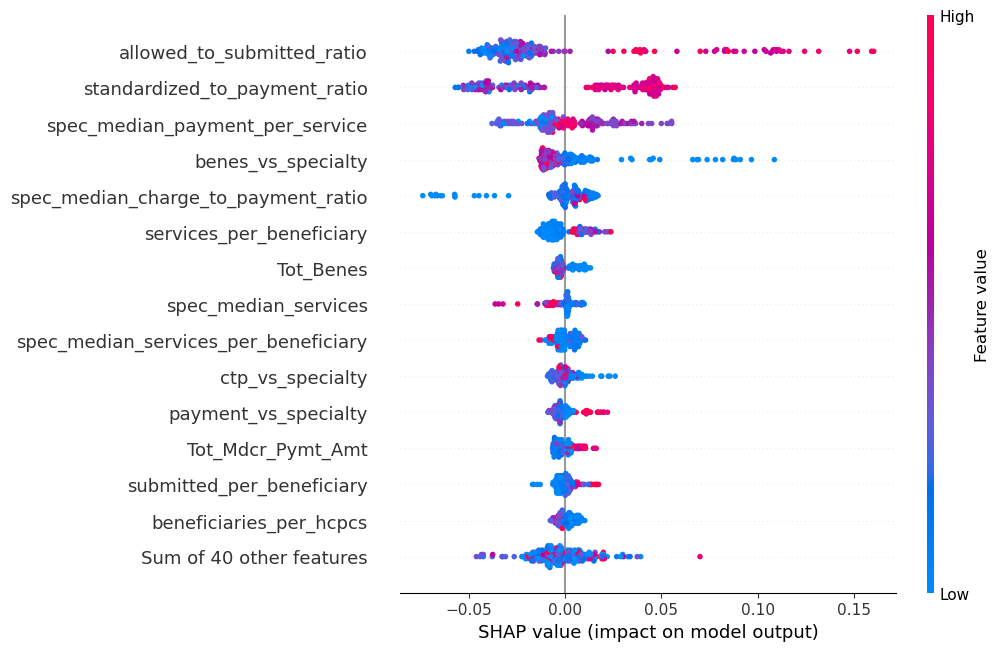

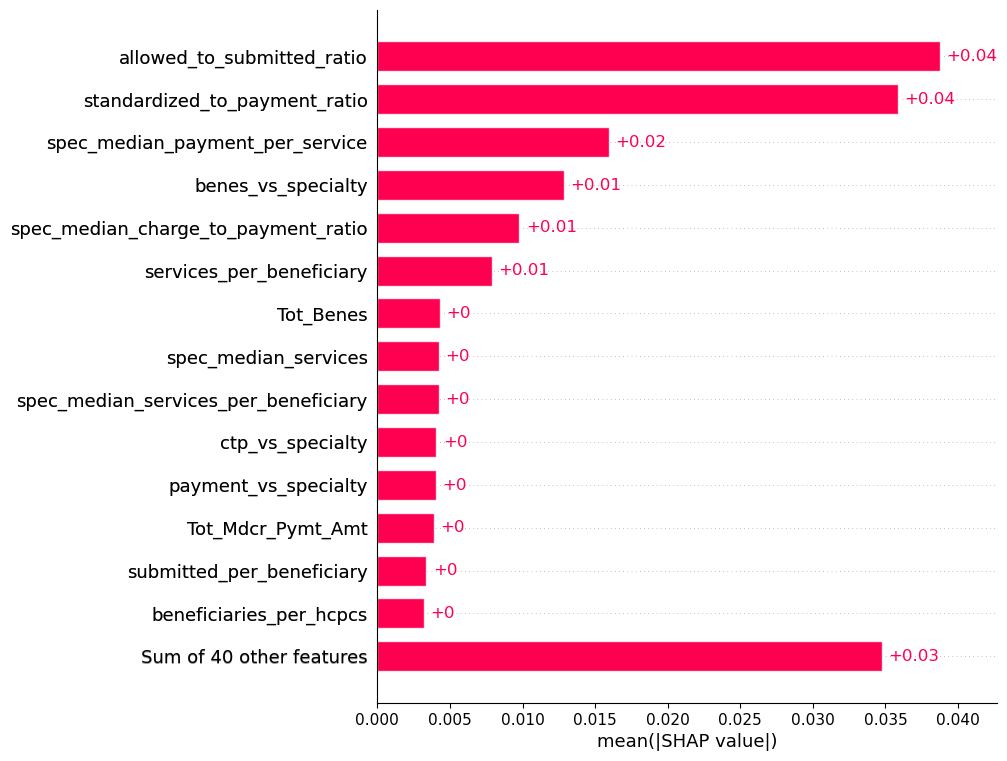

In [29]:
import shap
shap.initjs()

sample_size = min(200, len(X_test))
X_sample = X_test.sample(n=sample_size, random_state=42)

background = X_train.sample(n=100, random_state=42)
explainer   = shap.Explainer(improved_xgb.predict_proba, background)
shap_values = explainer(X_sample)

# shap_values has 2 outputs (class 0 and class 1), take class 1
shap_values_fraud = shap_values[..., 1]

print('SHAP values computed.')
shap.plots.beeswarm(shap_values_fraud, max_display=15)
shap.plots.bar(shap_values_fraud, max_display=15)

Predicted fraud probability: 0.34798306


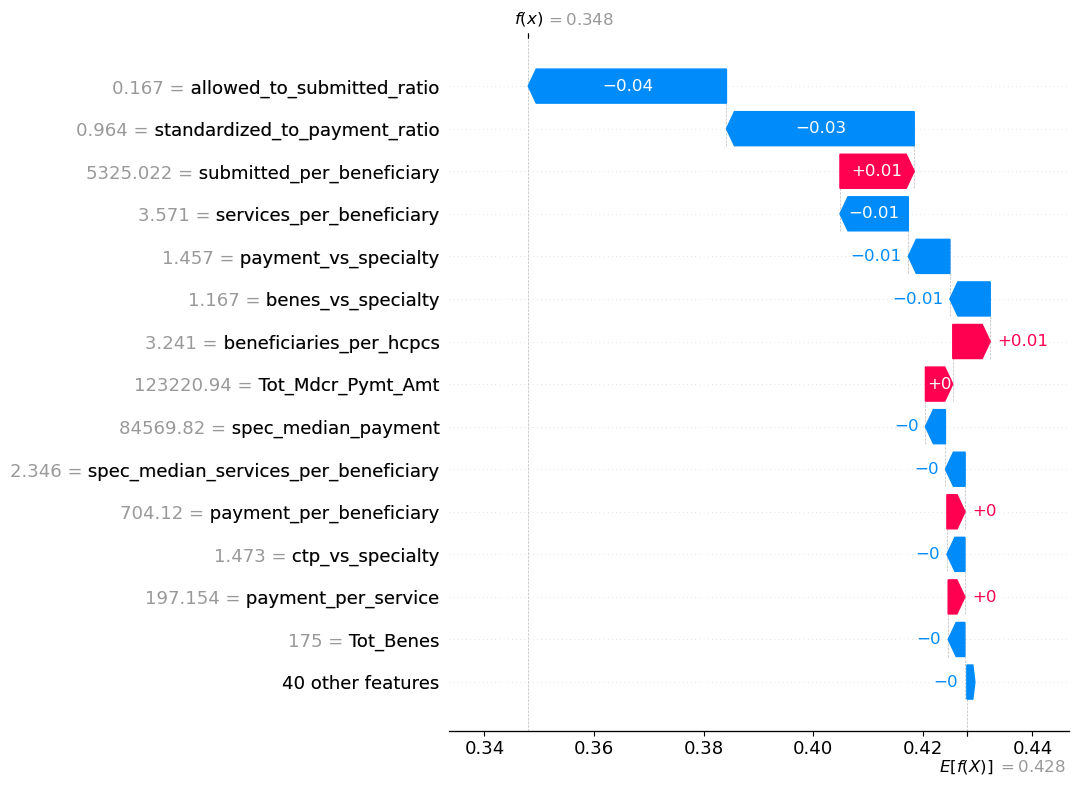


Top 15 Features (SHAP):
                             Feature  Mean_Abs_SHAP
          allowed_to_submitted_ratio       0.038736
       standardized_to_payment_ratio       0.035865
     spec_median_payment_per_service       0.015963
                  benes_vs_specialty       0.012851
 spec_median_charge_to_payment_ratio       0.009776
            services_per_beneficiary       0.007895
                           Tot_Benes       0.004289
                spec_median_services       0.004219
spec_median_services_per_beneficiary       0.004214
                    ctp_vs_specialty       0.004069
                payment_vs_specialty       0.004011
                   Tot_Mdcr_Pymt_Amt       0.003869
           submitted_per_beneficiary       0.003378
             beneficiaries_per_hcpcs       0.003210
                 spec_median_payment       0.003142


In [31]:
# ============================================================
# CELL 19 — SHAP Waterfall for single prediction
# ============================================================
sample_index = 0
print('Predicted fraud probability:',
      improved_xgb.predict_proba(X_sample.iloc[[sample_index]])[:, 1][0])

shap.plots.waterfall(shap_values_fraud[sample_index], max_display=15)

shap_importance = pd.DataFrame({
    'Feature':       X_sample.columns,
    'Mean_Abs_SHAP': np.abs(shap_values_fraud.values).mean(axis=0)
}).sort_values('Mean_Abs_SHAP', ascending=False)

os.makedirs('../data/processed', exist_ok=True)
shap_importance.to_csv('../data/processed/shap_importance_undersampled_xgb.csv', index=False)
print('\nTop 15 Features (SHAP):')
print(shap_importance.head(15).to_string(index=False))

## 15. Cross-Validation

In [ ]:

print('Running 5-fold Cross Validation...')

cv_5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'roc_auc':       'roc_auc',
    'avg_precision': 'average_precision',
    'recall':        'recall',
    'f1':            'f1'
}

# BRF CV
brf_cv = BalancedRandomForestClassifier(
    n_estimators=200, max_depth=10,
    sampling_strategy='auto', replacement=True,
    bootstrap=True, n_jobs=-1, random_state=42
)
cv_brf = cross_validate(brf_cv, X_train, y_train, cv=cv_5, scoring=scoring, n_jobs=-1)

# XGBoost CV
spw = (y_train == 0).sum() / (y_train == 1).sum()
xgb_cv = XGBClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=4,
    min_child_weight=3, gamma=1, subsample=0.8,
    colsample_bytree=0.8, reg_alpha=1, reg_lambda=2,
    scale_pos_weight=spw, random_state=42, n_jobs=-1, eval_metric='logloss'
)
cv_xgb = cross_validate(xgb_cv, X_train, y_train, cv=cv_5, scoring=scoring, n_jobs=-1)

cv_summary = pd.DataFrame({
    'Model':           ['Balanced RF', 'XGBoost'],
    'ROC-AUC':         [np.mean(cv_brf['test_roc_auc']),       np.mean(cv_xgb['test_roc_auc'])],
    'Avg Precision':   [np.mean(cv_brf['test_avg_precision']), np.mean(cv_xgb['test_avg_precision'])],
    'Recall':          [np.mean(cv_brf['test_recall']),        np.mean(cv_xgb['test_recall'])],
    'F1':              [np.mean(cv_brf['test_f1']),            np.mean(cv_xgb['test_f1'])]
})

print('\nCross-Validation Results:')
print(cv_summary.to_string(index=False))

Running 5-fold Cross Validation...

Cross-Validation Results:
      Model  ROC-AUC  Avg Precision  Recall       F1
Balanced RF 0.703333       0.241954    0.66 0.249534
    XGBoost 0.678439       0.244300    0.22 0.254906


## 16. Save Models

In [ ]:

os.makedirs('../src/models', exist_ok=True)

joblib.dump(improved_xgb,          '../src/models/improved_xgb_undersampled.pkl')
joblib.dump(brf,                   '../src/models/brf_undersampled.pkl')
joblib.dump(list(X_train.columns), '../src/models/model_columns_undersampled.pkl')

ensemble_metadata = {
    'w_xgb':     float(best_weights[0]),
    'w_brf':     float(best_weights[1]),
    'threshold': 0.5,
    'note':      'Trained on undersampled data (10:1 ratio, random_state=42)'
}

with open('../src/models/ensemble_config_undersampled.json', 'w') as f:
    json.dump(ensemble_metadata, f, indent=4)

print('Models saved:')
print('  src/models/improved_xgb_undersampled.pkl')
print('  src/models/brf_undersampled.pkl')
print('  src/models/model_columns_undersampled.pkl')
print('  src/models/ensemble_config_undersampled.json')
print('\nEnsemble config:', ensemble_metadata)

Models saved:
  src/models/improved_xgb_undersampled.pkl
  src/models/brf_undersampled.pkl
  src/models/model_columns_undersampled.pkl
  src/models/ensemble_config_undersampled.json

Ensemble config: {'w_xgb': 0.6, 'w_brf': 0.4, 'threshold': 0.5, 'note': 'Trained on undersampled data (10:1 ratio, random_state=42)'}
